In [49]:
import sys
print(sys.executable)

import numpy, scipy, matplotlib
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("matplotlib", matplotlib.__version__)


C:\Users\razan\anaconda3\envs\anaconda-2025.12-py3.13\python.exe
numpy 2.3.5
scipy 1.16.3
matplotlib 3.10.6


In [50]:
#libraries
import numpy as np
import matplotlib.pyplot as plt


# Step 1: Generate a synthetic extracellular recording that mimics the real data.
**Why synthetic data?** To benchmark denoisers fairly, I need the *true clean signal* to
compare against. Real recordings never come with a clean reference. So I build the clean
signal myself, add noise, denoise it, then compare back to the known clean version:

`clean (I build it) → + noise → noisy → [denoise] → compare back to clean`

## Stage 1: Build a clean recording:
- A real extracellular action potential is **asymmetric**: a sharp, deep negative trough,
  then a smaller and slower positive rebound.
- Ricker is **symmetric**, so it can't match this. DoG builds the trough and rebound as two
  separate Gaussians, so I can control them independently (`peak_ratio` sets how big the
  rebound is relative to the trough).
- Also, `scipy.signal.ricker` was removed in recent SciPy versions, so it may not
  import. DoG is just `np.exp` — no dependency.

Template is normalised so the trough = **−1.0**, so the channel map can scale it cleanly

In [3]:
def make_spike_template (fs=20000, duration_ms=2.0,
                         trough_pos=0.4, trough_width=0.12,
                         peak_pos=0.6, peak_width=0.25, peak_ratio=0.4):
    """
    One extracellular AP template, normalised so teh trough (min) = -1.0.
    Built as a difference of gaussians : sharp negative trough + slower positive rebound. 
    possitions are fractions of the window(0..1).
    """
    n = int(fs * duration_ms / 1000)   # samples in the window
    t = np.linspace(0, 1, n)    # normalise time 0..1

    trough = -np.exp(-((t - trough_pos)**2) / (2 * trough_width**2))
    peak = peak_ratio * np.exp(-((t - peak_pos)**2) / (2 * peak_width**2))

    wave = trough + peak
    wave = wave / np.abs(wave.min())   # normalise so min = -1.0
    return t, wave

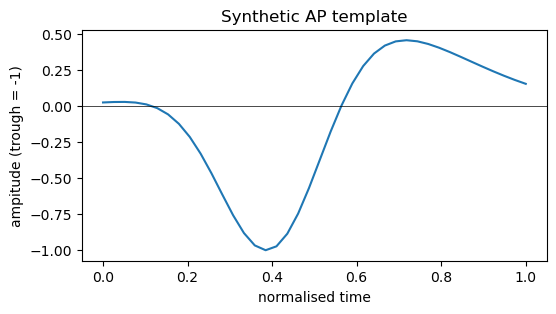

In [4]:
t, wave = make_spike_template()
plt.figure(figsize=(6,3))
plt.plot(t, wave)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("normalised time"); plt.ylabel("ampitude (trough = -1)")
plt.title("Synthetic AP template"); plt.show()

## Stage 2:  channel map (how strong the spike is on each channel):
`amp` = 32 numbers, one per electrode contact. Channel 19 = 1.0 (strongest), fading through
strong neighbours (9, 14, 25, 30) and weak ones (3, 10, 12, 16, 17, 32), and 0 on the rest.

**Physical meaning:** one fibre fires; contacts physically closer to it record a stronger
signal, farther ones weaker, distant ones nothing. So `amp` is the fibre's **spatial
footprint across the electrode**.

**Why this matters (the spine of the project):** each fibre has its own unique pattern across
the 32 channels — its spatial "fingerprint." Sorting tells fibres apart by comparing these
cross-channel patterns, not just spike shape. (My earlier result: F1 ~0.05 on 1 channel →
~0.51 with 3–5 channels.)

> **Viva one-liner:** Per-channel denoising treats channels independently, so it doesn't
> preserve the cross-channel amplitude ratios — and those ratios are exactly what sorting
> relies on. That's why I argue for **joint (multi-channel) denoising**, which cleans all
> channels together and can preserve the pattern.

In [15]:
# How strong the spike looks in each channel
n_channels = 32
amp = np.zeros(n_channels)  # 32 zeros - every channel starts silent 

# the good unit similart to the actual data
amp[18] = 1.0    # channel 19 (19 - 1 = index 18)

# strong neighbours (channels 9, 14, 25, 30)
amp[8] = 0.6   # channel 9
amp[13] = 0.45  # channel 14
amp[24] = 0.7  # channel 25
amp[29] = 0.5   # channel 30

# weak (channels 3, 10, 12, 16, 17, 32
amp[2] = 0.15   # channel 3
amp[9] = 0.1    # channel 10
amp[11] = 0.25  # channel 12
amp[15] = 0.16 # channel 16
amp[16] = 0.22  # channel 17
amp[31] = 0.24  # channel 32

for ch in [19, 9, 14, 25, 30, 3, 10, 12, 16, 17, 32]:
    print(f"channel {ch:2d} -> index {ch-1:2d} -> amplitude {amp[ch-1]}")

channel 19 -> index 18 -> amplitude 1.0
channel  9 -> index  8 -> amplitude 0.6
channel 14 -> index 13 -> amplitude 0.45
channel 25 -> index 24 -> amplitude 0.7
channel 30 -> index 29 -> amplitude 0.5
channel  3 -> index  2 -> amplitude 0.15
channel 10 -> index  9 -> amplitude 0.1
channel 12 -> index 11 -> amplitude 0.25
channel 16 -> index 15 -> amplitude 0.16
channel 17 -> index 16 -> amplitude 0.22
channel 32 -> index 31 -> amplitude 0.24


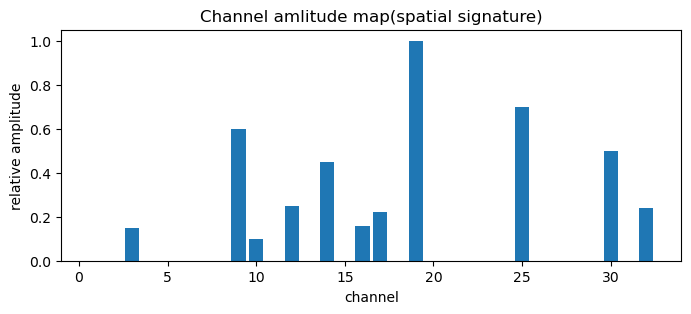

In [14]:
# plot
plt.figure(figsize=(8,3))
plt.bar(np.arange(1, n_channels+1), amp)
plt.xlabel("channel"); plt.ylabel("relative amplitude")
plt.title("Channel amlitude map(spatial signature)")
plt.show()

## Stage 3: Spike times (when spikes happen)
Evoked case: fibres fire at a fixed delay after each stimulus (TTL).
- phase 1 timing: 0.25Hz = 1 pulse every 4 s, 221 pulses
- `ttl_times = np.arange(n_pulses) * stim_period` -> 0, 4, 8, … 880 s.
- `spike_times = ttl_times + latency` — the **latency** is the travel delay from stimulus to
  electrode. It's fixed because it's the same fibre responding to the same stimulus each time.

Because I *define* these times, they are perfect **ground truth** for testing detection later.

In [18]:
# Spike time: when do these spike happen
fs = 20000 # HZ, must match the template
stim_period = 4.0  # seconds between pulses (0.25 Hz)
n_pulses = 221
latency = 0.003   # seconds - fixed delay from stimulus to spike (pick a realistic value, ~2-4ms)

# TTl (stimulus) times in seconds: 0, 4, 8 for 221 pulses
ttl_times = np.arange(n_pulses) * stim_period
spike_times = ttl_times + latency 

print("number of TTLs:", len(ttl_times))
print("first 3 TTL times (s):", ttl_times[:3])
print("last TTL time (s):", ttl_times[-1])
print("first 3 spikes times (s):", spike_times[:3]) 

number of TTLs: 221
first 3 TTL times (s): [0. 4. 8.]
last TTL time (s): 880.0
first 3 spikes times (s): [3.000e-03 4.003e+00 8.003e+00]


## Stage 4: assemble the recording
Empty (32 × N) canvas of zeros; for each spike, stamp `template × amp[ch]` onto every channel
at that spike's sample index. Result: clean multi-channel recording with the correct spatial
signature (channel 19 tallest at −1.0, scaling down correctly).

**Bug learned:** `rec[ch, start:end] += ...` uses `+=` (accumulate). Re-running the loop
without re-zeroing `rec` stacks spikes on top of themselves (trough came out −2.0 instead of
−1.0 — exactly doubled). Fix: zero the canvas *inside* the same cell, so it's safe to re-run.
General rule: any cell that uses `+=` is unsafe to re-run alone; exact 2×/3× values are the tell.


In [20]:
# Assemble the recording
n_dev_spikes = 10
dev_spikes = spike_times[:n_dev_spikes]

# recordings needs to be long enough to hold the last dev spike + a full template after it
duration_s = dev_spikes[-1] + 0.01   # last spike time + 10 ms padding 
n_samples = int(duration_s * fs)   # total samples in the recordings

rec = np.zeros((n_channels, n_samples))   # 32 X N canvas, all silent
print("recording shape:", rec.shape)

recording shape: (32, 720260)


In [26]:
# Stamping logic
""" 
for each spike: convert its time (seconds) to a sample index ( where in the array it starts)
add the template X each channel's amplitude at that position
"""
n_template = len(wave)   # how many samples the tempalte spans (40)

for t_spike in dev_spikes:
    start = int(t_spike * fs)    # seconds -> sample index
    end = start + n_template  # template occupes start;end

    # stamp onto every channel scaled by that channel's amplitude
    for ch in range(n_channels):
        rec[ch, start:end] += wave * amp[ch]

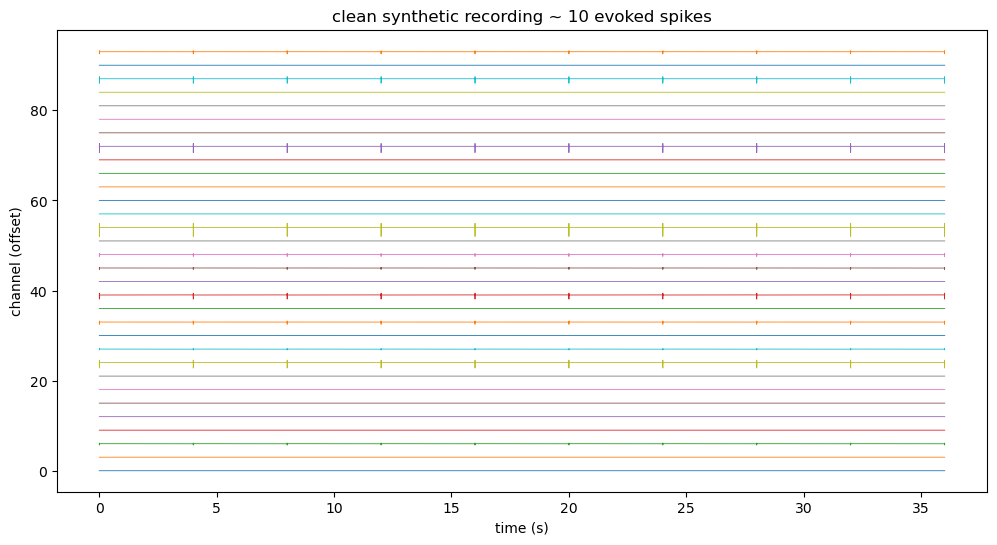

In [32]:
t_axis = np.arange(n_samples) / fs   # x-axis in seconds

plt.figure(figsize=(12, 6))
offset = 3   # vertical spacing so channels dont overlap
for ch in range(n_channels):
    plt.plot(t_axis, rec[ch] + ch * offset, lw=0.6)
plt.xlabel("time (s)"); plt.ylabel("channel (offset)")
plt.title("clean synthetic recording ~ 10 evoked spikes")
plt.show()

channel 19: trough = -2.000, peak-to-peak = 2.916
channel 25: trough = -1.400, peak-to-peak = 2.041
channel  9: trough = -1.200, peak-to-peak = 1.750
channel  3: trough = -0.300, peak-to-peak = 0.437
channel  1: trough = 0.000, peak-to-peak = 0.000


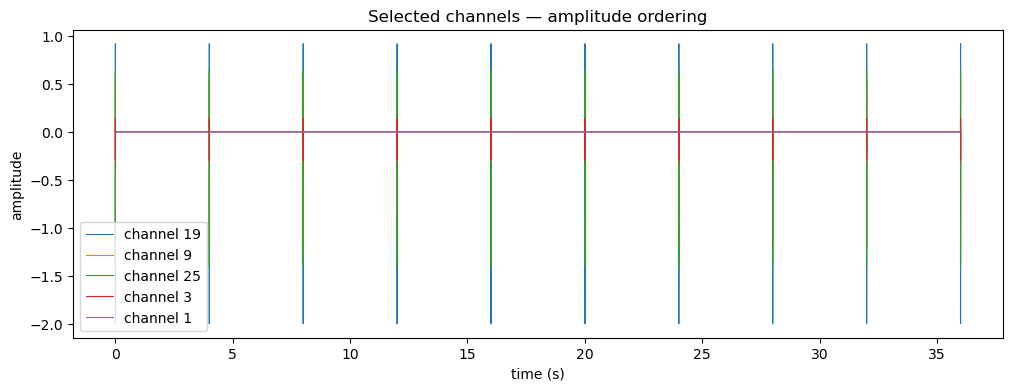

In [33]:
for ch in [18, 24, 8, 2, 0]:   # channels 19, 25, 9, 3, 1
    print(f"channel {ch+1:2d}: trough = {rec[ch].min():.3f}, peak-to-peak = {np.ptp(rec[ch]):.3f}")
plt.figure(figsize=(12, 4))
for ch in [18, 8, 24, 2, 0]:   # channel 19, 9, 25, 3, 1  (indices)
    plt.plot(t_axis, rec[ch], lw=0.8, label=f"channel {ch+1}")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Selected channels — amplitude ordering")
plt.legend()
plt.show()

In [34]:
rec = np.zeros((n_channels, n_samples))

In [35]:
n_template = len(wave)

for t_spike in dev_spikes:
    start = int(t_spike * fs)
    end = start + n_template
    for ch in range(n_channels):
        rec[ch, start:end] += wave * amp[ch]

In [36]:
for ch in [18, 24, 8, 2, 0]:
    print(f"channel {ch+1:2d}: trough = {rec[ch].min():.3f}")

channel 19: trough = -1.000
channel 25: trough = -0.700
channel  9: trough = -0.600
channel  3: trough = -0.150
channel  1: trough = 0.000


## Stage 5: Add noise

`noise = np.random.normal(0, noise_std, rec.shape)` then `noisy = rec + noise`.

- `noise_std = 0.1` vs channel-19 spike depth 1.0 → spike ~10× noise (easy on ch19).
- Same noise on channel 3 (depth 0.15) → spike barely above noise (hard).
- **Key intuition:** the same noise makes strong channels easy and weak channels hard — which
  is why pooling across channels (joint denoising) matters. Later: sweep `noise_std` to plot
  performance vs SNR.


In [39]:
# One line of noise
noise_std = 0.1
noise = np.random.normal(0, noise_std, rec.shape) # random numbers, bell-curve distribtion, mean 0(noise is equally likely + or -), standard deviation 0.1( how big the wiggles are), and rec.shape so the noise array is exactly 32XN
noisy = rec + noise

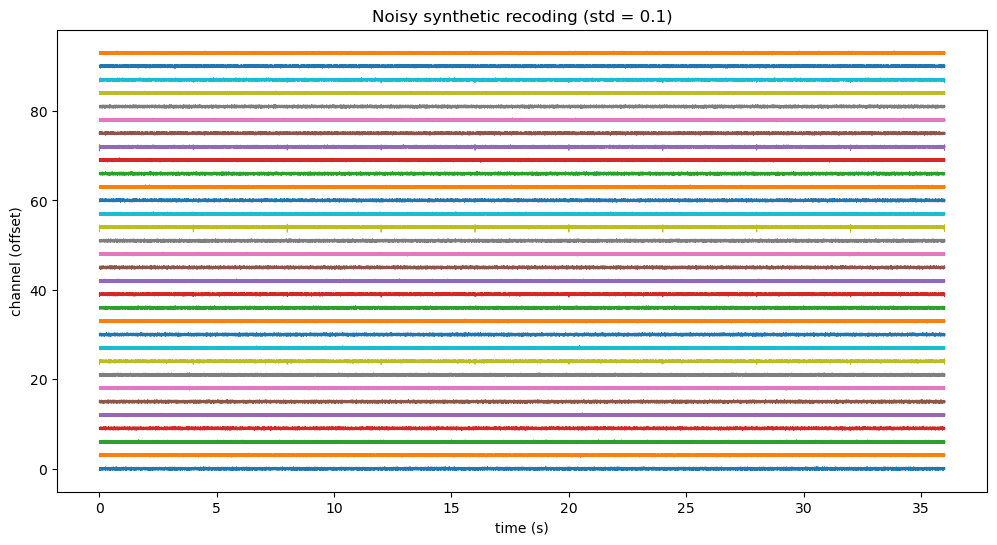

In [43]:
#plot it
t_axis = np.arange(n_samples) / fs
plt.figure(figsize=(12, 6))
offset = 3
for ch in range(n_channels):
    plt.plot(t_axis, noisy[ch] + ch * offset, lw=0.6)
plt.xlabel("time (s)"); plt.ylabel("channel (offset)")
plt.title("Noisy synthetic recoding (std = 0.1)")
plt.show()
    

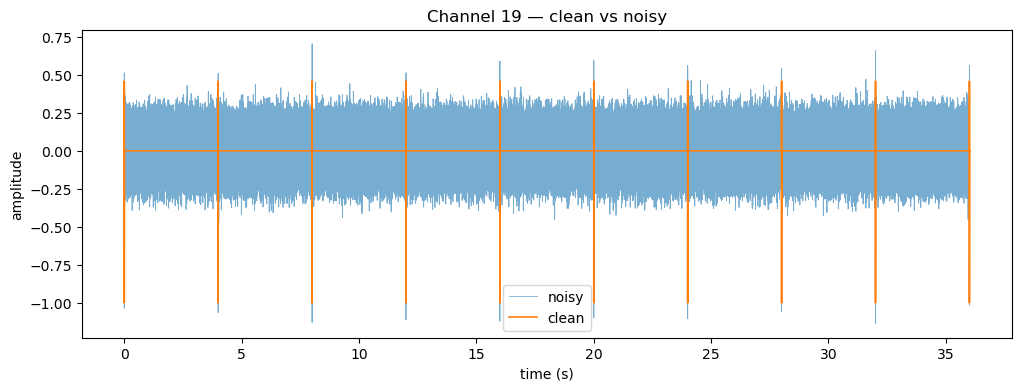

In [44]:
ch = 18  # channel 19 (the good unit)
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — clean vs noisy")
plt.legend()
plt.show()

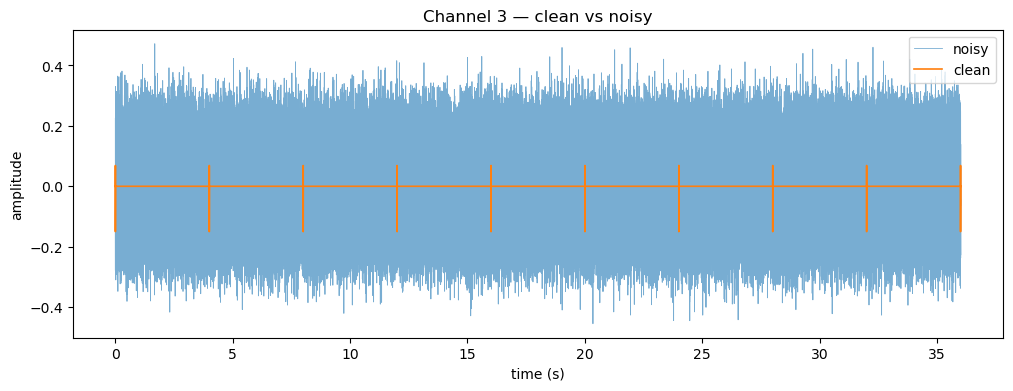

In [45]:
ch = 2 # channels 3 (weak)
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 3 — clean vs noisy")
plt.legend()
plt.show()

## Stage 6: realistic noise
**Standard Gaussian white noise** distributions do not accurately mimic real extracellular neural or peripheral nerve preparations, as they assume a flat power spectral density that fails to challenge filters in-band. Electrophysiological environments present a multi-layered noise profile [Buccino & Einevoll., 2020].To construct high-fidelity synthetic data, three physical layers are added: **Aperiodic pink (\(1/f\))** noise to represent the combined effect of electrode-tissue thermal impedance and un-sortable, distant background Multi-Unit Activity (MUA). **Deterministic mains interference (50 Hz)** to simulate ambient electromagnetic leakage. An adjustable spatial cross-channel correlation coefficient ('knob') to split the noise into independent thermal channel fluctuations and global, common-mode components. This control sets the conditions under which purely temporal filters fail and multi-channel spatial methods, such as Common Average Referencing (CAR)—become advantageous [Ludwig et al., 2009].

### White noise
`np.random.normal`. Equal power at all frequencies (flat spectrum). Looks like uniform fuzz, no slow structure. Baseline case, but not realistic on its own.
### Pink (1/f) noise
More power at low frequencies, less at high (power falls off as 1/f). Looks like slow wandering/drift rather than uniform fuzz. Real neural background noise is 1/f, so this is more realistic than white.
Built via FFT: take white noise to the frequency domain (`np.fft.rfft`), divide each component by sqrt(frequency) to suppress high frequencies and boost low, transform back (`np.fft.irfft`). Skip frequency bin 0 (DC term) to avoid dividing by zero. So pink is white noise with its frequency content reshaped.

In [54]:
def make_pink_noise(n_samples, fs):
    """
    Pink (1/f) noise: white noise shaped so power falls off as 1.frequency.
    method: FFT white noise -> divide by sqrt(f) -> inverse FFT.
    """
    # white noise first
    white = np.random.normal(0, 1, n_samples)

    # frequency domain
    spectrum = np.fft.rfft(white)

    # build the frequencies for each spectrum bin
    freqs = np.fft.rfftfreq(n_samples, d=1/fs)

    # scale: divide each frequency component by sqrt(f), this is what titls the flat white spectrum into 1/f pink. 
    scaling = np.ones_like(freqs)
    scaling[1:] = 1 / np.sqrt(freqs[1:])  # skip index 0 to avoid /0
    spectrum_pink = spectrum * scaling

    # time domain
    pink = np.fft.irfft(spectrum_pink, n=n_samples)

    # normalise to std = 1 so itscales later like white noise
    pink = pink / np.std(pink)
    return pink

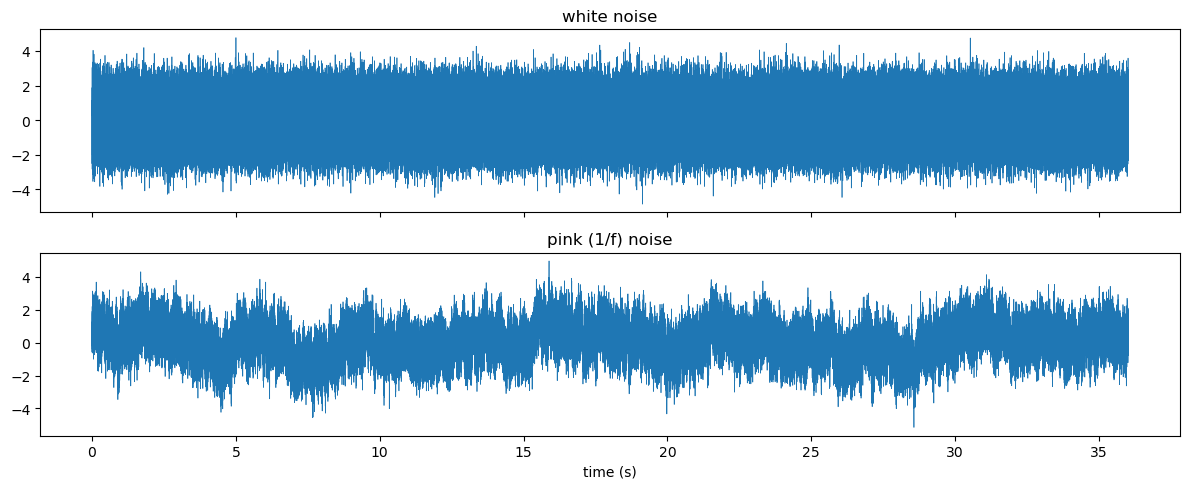

In [55]:
n = n_samples    #reusing the recording length
white = np.random.normal(0, 1, n)
pink = make_pink_noise(n, fs)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(np.arange(n)/fs, white, lw=0.5); ax[0].set_title("white noise")
ax[1].plot(np.arange(n)/fs, pink, lw=0.5); ax[1].set_title("pink (1/f) noise")
ax[1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

### 50 Hz mains
UK mains electricity is 50 Hz (60 Hz in US). Powered devices near the rig radiate a 50 Hz field that the electrode and cables pick up. A steady hum on top of the signal. Modelled as a sine wave: `mains_amp * np.sin(2*pi*50*t)`. Present in almost all real recordings.

Put in the shared (common-mode) part because the external field hits all channels at once, every channel picks up nearly the same hum. This is exactly the kind of noise CAR/CMR can remove.


In [56]:
# 50 Hz mains hum
def make_mains(n_samples, fs, mains_amp=0.2, freq=50):
    """
    50 Hz mains interference, A sine wave at the mains frequency 
    """

    t = np.arange(n_samples) / fs   # time in seconds
    mains = mains_amp * np.sin(2 * np.pi * freq * t)
    return mains

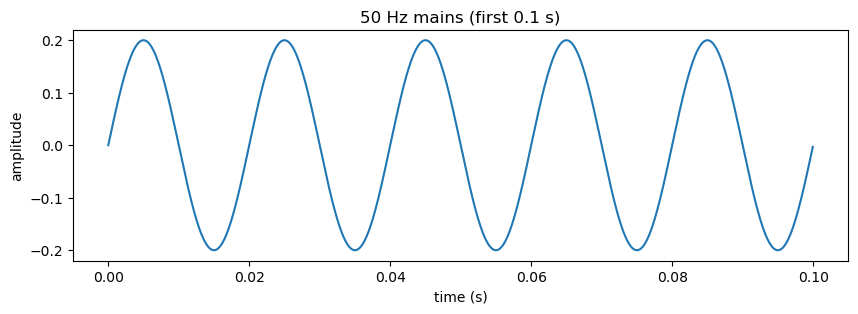

In [58]:
mains = make_mains(n_samples, fs)
n_show = int(0.1 * fs)   # first 0.1 s

plt.figure(figsize=(10, 3))
plt.plot(np.arange(n_show)/fs, mains[:n_show])
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("50 Hz mains (first 0.1 s)")
plt.show()

### Cross-channel structure — `common_frac`
Controls how much noise is shared across channels (common-mode) vs independent per channel.
- 0.0 = all independent (each channel its own noise)
- 1.0 = all shared (same noise on every channel)
- 0.5 = half and half (sensible default; real recordings have both)

Why it matters:
- Shared noise is EASIER to remove: a multi-channel method can compare channels, see the same wiggle on all of them, and subtract it. (Only *some* channels show a real spike, so anything on *all* channels is noise.)
- Independent noise is HARDER: nothing shared across channels to exploit.

This is the knob that sets up the central experiment: with high common_frac, a joint (multi-channel) denoiser should beat a per-channel one, because only the joint method can see across channels.

In [68]:
# now combine white + pink + 50 Hz noise
def make_noise(n_channels, n_samples, fs, white_std=0.1, pink_std=0.1, mains_amp=0.05, common_frac=0.5):
    """
    layered noise for a multi-channel recording
    - white + pink + 50 Hz mains
    - common_frac sets how much noise is shared across channels (common-mode)
       vs independent per channel. 0 = all independent, 1 = all shared.
    returns array shape (n_channels, n_samples)
    """
    noise = np.zeros((n_channels, n_samples))

    # independent part: different noise on each channel
    for ch in range(n_channels):
        w = white_std * np.random.normal(0, 1, n_samples)
        p = pink_std * make_pink_noise(n_samples, fs)
        noise[ch] = (1 - common_frac) * (w + p)

    # common-mode part: ONE noise trace shared by all channels
    w_common = white_std * np.random.normal(0, 1, n_samples)
    p_common = pink_std * make_pink_noise(n_samples, fs)
    mains = make_mains(n_samples, fs, mains_amp)
    shared = w_common + p_common + mains

    # add the same shared trace to every channel
    for ch in range(n_channels):
        noise[ch] += common_frac * shared

    return noise

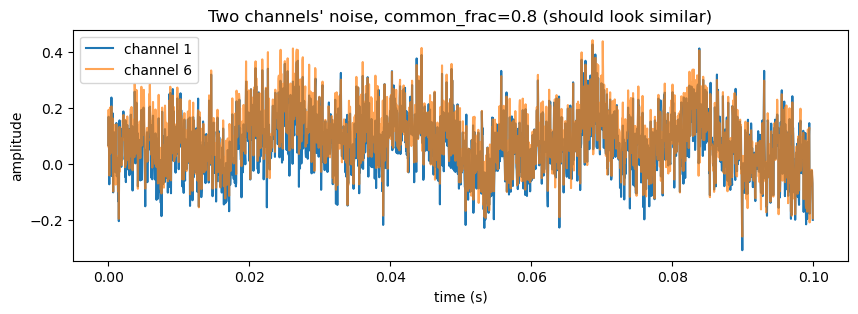

In [69]:
test_noise = make_noise(n_channels, n_samples, fs, common_frac=0.8)
n_show = int(0.1 * fs)
plt.figure(figsize=(10, 3))
plt.plot(np.arange(n_show)/fs, test_noise[0, :n_show], label="channel 1")
plt.plot(np.arange(n_show)/fs, test_noise[5, :n_show], label="channel 6", alpha=0.7)
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Two channels' noise, common_frac=0.8 (should look similar)")
plt.legend()
plt.show()


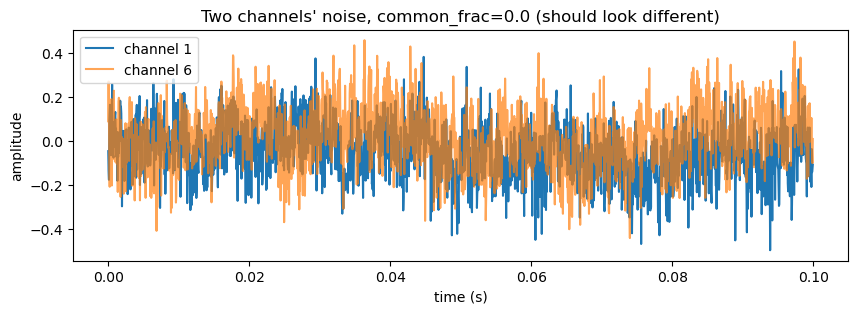

In [70]:
test_noise = make_noise(n_channels, n_samples, fs, common_frac=0.0)

n_show = int(0.1 * fs)
plt.figure(figsize=(10, 3))
plt.plot(np.arange(n_show)/fs, test_noise[0, :n_show], label="channel 1")
plt.plot(np.arange(n_show)/fs, test_noise[5, :n_show], label="channel 6", alpha=0.7)
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Two channels' noise, common_frac=0.0 (should look different)")
plt.legend()
plt.show()

In [71]:
print("channel 1 std:", test_noise[0].std())
print("channel 6 std:", test_noise[5].std())
print("any nonzero in ch6?:", np.any(test_noise[5] != 0))


channel 1 std: 0.14137861542589727
channel 6 std: 0.14142840456929884
any nonzero in ch6?: True


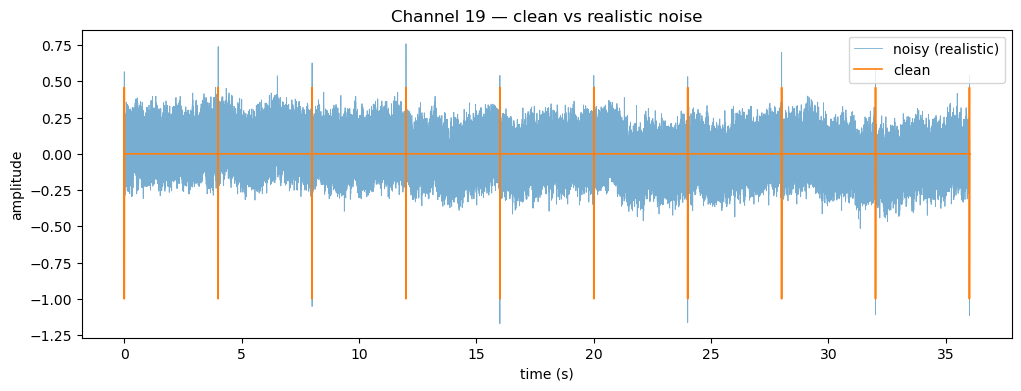

In [75]:
noise = make_noise(n_channels, n_samples, fs, common_frac=0.5)
noisy = rec + noise
ch = 18  # channel 19
t_axis = np.arange(n_samples) / fs
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy (realistic)")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — clean vs realistic noise")
plt.legend()
plt.show()

## Admore sines

In [90]:
def make_mains(n_samples, fs, mains_amp=0.05, base_freq=50, n_harmonics=4):
    """
    Mains interference: 50 Hz + harmonics (100, 150, 200 Hz).
    Each harmonic n has amplitude mains_amp/n (higher harmonics weaker).
    """
    t = np.arange(n_samples) / fs
    mains = np.zeros(n_samples)
    for n in range(1, n_harmonics + 1):      # n = 1, 2, 3, 4
        freq = base_freq * n                 # 50, 100, 150, 200
        amp = mains_amp / n                  # full, half, third, quarter
        mains += amp * np.sin(2 * np.pi * freq * t)
    return mains

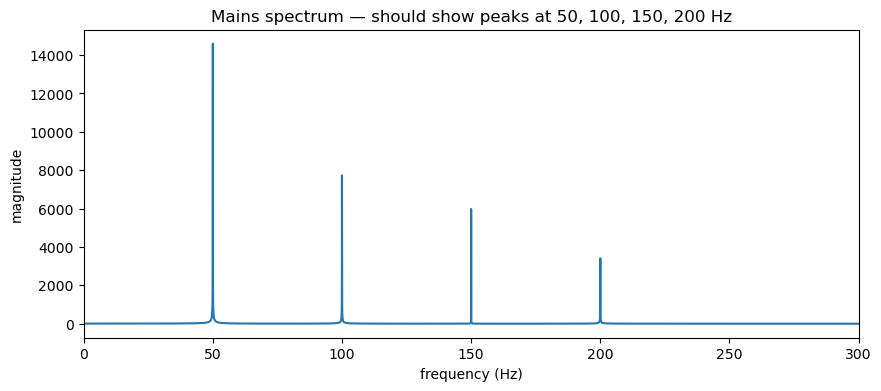

In [91]:
mains = make_mains(n_samples, fs)
# frequency spectrum
spectrum = np.abs(np.fft.rfft(mains))
freqs = np.fft.rfftfreq(n_samples, d=1/fs)

plt.figure(figsize=(10, 4))
plt.plot(freqs, spectrum)
plt.xlim(0, 300)           # zoom to 0-300 Hz so we can see the peaks
plt.xlabel("frequency (Hz)"); plt.ylabel("magnitude")
plt.title("Mains spectrum — should show peaks at 50, 100, 150, 200 Hz")
plt.show()

In [88]:
test = make_noise(n_channels, n_samples, fs, common_frac=0.5)
print("shape:", test.shape)
print("channel 0 std:", test[0].std())

shape: (32, 720260)
channel 0 std: 0.1021304809720084


# Step 2: Denoising

In [92]:
print(fs, n_channels, n_samples)
print("noisy shape:", noisy.shape)

20000 32 720260
noisy shape: (32, 720260)


## First: Bandpadd filter
The spikes are fast and sharp transients; they live in a specific frequency band, roughly 300-3000 Hz. The noise is spread across all frequencies: pink noise dominates the low end (slow drift, below 300 Hz), and there's hiss up high. **A bandpass filter** keeps the 300-3000 Hz band and discards everything outside of it, so it strips the low-frequency pink drift and high-frequency junk, leaving the spikes band cleaner. 
### Evaluation metric to compare the denoisers: **RMSE**
Root mean squared error between the denoised signal and the clean truth. It captures noise left behind and signal damage; both increase RMSE. Lower RMSE means closer to the truth, consequently a better denoiser. 

In [93]:
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):
    return butter(order, [lowcut, highcut], fs=fs, btype='band')

def denoise_bandpass(noisy, fs, lowcut=300, highcut=3000, order=4):
    """
    Per-channel bandpass filter (300-3000Hz). Keeps the spike band, removes low-freq drift and high-freq hiss.
    filtfil = zero phase shift, so spike timing is preserved.
    input/output: (n_channels, n_samples).
    """
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    denoised = filtfilt(b, a, noisy, axis=1)
    return denoised

In [95]:
denoised = denoise_bandpass(noisy, fs)
print("shape", denoised.shape)

shape (32, 720260)


C:\Users\razan\anaconda3\envs\anaconda-2025.12-py3.13\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


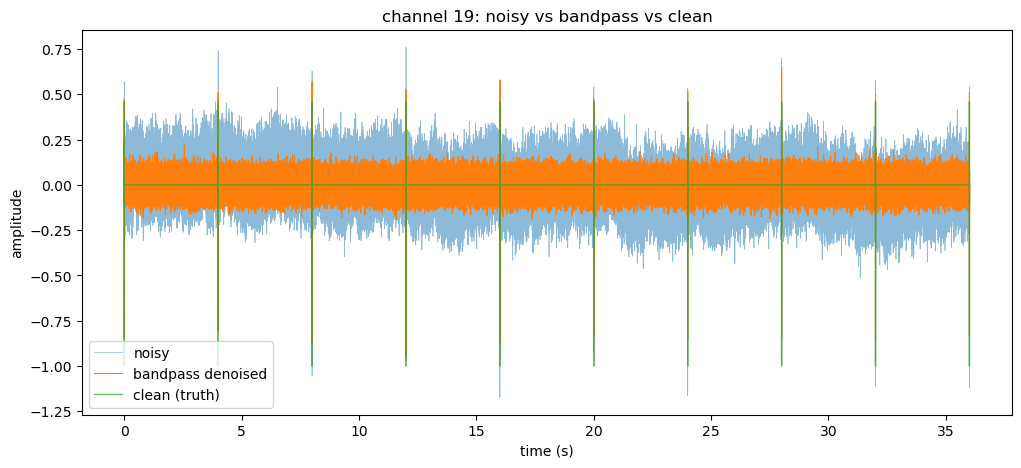

In [97]:
ch = 18  # channel 19
t_axis = np.arange(n_samples) / fs

plt.figure(figsize=(12, 5))
plt.plot(t_axis, noisy[ch],  lw=0.5, alpha=0.5, label="noisy")
plt.plot(t_axis, denoised[ch], lw=0.8, label="bandpass denoised")
plt.plot(t_axis, rec[ch],  lw=1.0, alpha=0.7, label="clean (truth)")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("channel 19: noisy vs bandpass vs clean")
plt.legend()
plt.show()

In [99]:
print("clean spike trough:", rec[18].min())
print("denoised spike trough:", denoised[18].min())

clean spike trough: -1.0
denoised spike trough: -0.9370029232877335


In [100]:
denoised_150 = denoise_bandpass(noisy, fs, lowcut=150)
print("denoised trough (lowcut=150):", denoised_150[18].min())

denoised trough (lowcut=150): -1.0286085205697304


In [101]:
# RMSE
def rmse(denoised, clean):
    return np.sqrt(np.mean((denoised - clean) ** 2))

print("RMSE noisy vs clean:", rmse(noisy, rec))
print("RMSE bandpass vs clean:", rmse(denoised, rec))
print("RMSE bandpass -150 vs clean:", rmse(denoised_150, rec))

RMSE noisy vs clean: 0.1016475106320098
RMSE bandpass vs clean: 0.04388372870530337
RMSE bandpass -150 vs clean: 0.04708287375858494


In [111]:
# RMSE per channel
print("channel,  noisy RMSE,  bandpass RMSE")
for ch in range(n_channels):
    noisy_rmse = rmse(noisy[ch], rec[ch])  # one channel
    bp_rmse = rmse(denoised[ch], rec[ch])
    print(f" ch {ch+1:2d},     {noisy_rmse:.4f},      {bp_rmse:.4f}")

channel,  noisy RMSE,  bandpass RMSE
 ch  1,     0.1015,      0.0440
 ch  2,     0.1018,      0.0440
 ch  3,     0.1026,      0.0440
 ch  4,     0.1077,      0.0434
 ch  5,     0.1017,      0.0447
 ch  6,     0.1033,      0.0443
 ch  7,     0.0998,      0.0441
 ch  8,     0.1047,      0.0436
 ch  9,     0.0970,      0.0438
 ch 10,     0.0996,      0.0442
 ch 11,     0.0996,      0.0439
 ch 12,     0.1002,      0.0441
 ch 13,     0.1020,      0.0442
 ch 14,     0.1023,      0.0441
 ch 15,     0.0990,      0.0435
 ch 16,     0.0990,      0.0438
 ch 17,     0.0986,      0.0440
 ch 18,     0.1014,      0.0442
 ch 19,     0.1030,      0.0436
 ch 20,     0.1049,      0.0442
 ch 21,     0.1040,      0.0437
 ch 22,     0.1032,      0.0438
 ch 23,     0.1006,      0.0434
 ch 24,     0.1004,      0.0439
 ch 25,     0.1027,      0.0439
 ch 26,     0.0988,      0.0441
 ch 27,     0.1045,      0.0434
 ch 28,     0.1005,      0.0439
 ch 29,     0.1054,      0.0435
 ch 30,     0.0984,      0.0433
 ch

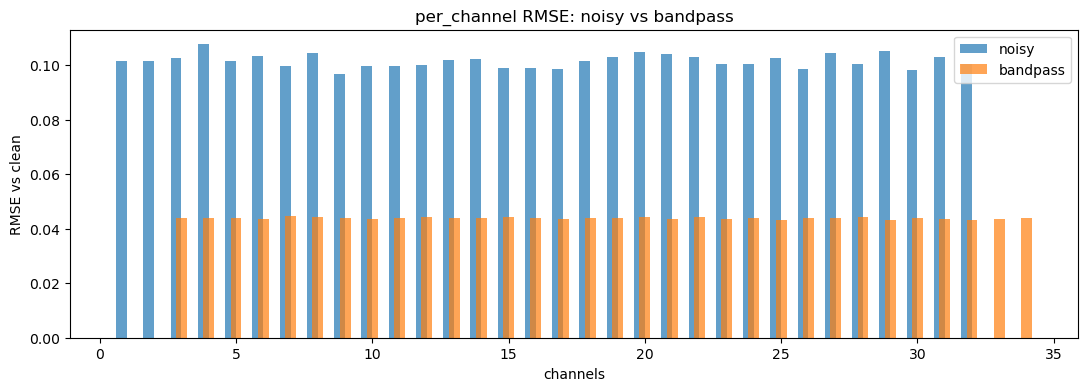

In [117]:
# plot
noisy_per_ch = np.array([rmse(noisy[ch], rec[ch]) for ch in range(n_channels)])
bp_per_ch = np.array([rmse(denoised[ch], rec[ch]) for ch in range(n_channels)])

x = np.arange(1, n_channels+1)
plt.figure(figsize=(13, 4))
plt.bar(x - 0.2, noisy_per_ch, width=0.4, label="noisy", alpha=0.7)
plt.bar(x + 2, bp_per_ch, width=0.4, label="bandpass", alpha=0.7)
plt.xlabel("channels"); plt.ylabel("RMSE vs clean")
plt.title("per_channel RMSE: noisy vs bandpass")
plt.legend()
plt.show()

In [123]:
#look at the spike instead of the whole recording (so look at the spike amplitude specificcaly)
print("channel,    clean trough,    bandpass trough,      % preserved")
for ch in [18, 24, 8, 2, 9, 0]:   # ch19, 25, 9, 3, 10, 1 (stron, weak, silent channels)
    clean_trough = rec[ch].min()
    bp_trough  = denoised[ch].min()
    if clean_trough !=0:
        pct = 100 * bp_trough / clean_trough
        print(f" ch {ch+1:2d},         {clean_trough:.3f},        {bp_trough:.3f},                {pct:.0f}%")
    else:
        print(f"  ch {ch+1:2d},        {clean_trough:.3f},        {bp_trough:.3f},                 (silent)")

channel,    clean trough,    bandpass trough,      % preserved
 ch 19,         -1.000,        -0.937,                94%
 ch 25,         -0.700,        -0.667,                95%
 ch  9,         -0.600,        -0.576,                96%
 ch  3,         -0.150,        -0.220,                147%
 ch 10,         -0.100,        -0.199,                199%
  ch  1,        0.000,        -0.207,                 (silent)


## Second: CMR (Common Median Reference) 
It takes the median across all channels at each time point subtract it from every channel. 
Common median has improved SNR for spike detection and doesn't generate spurious spikes the way mean-based referencing can when there are large transients Rolston, Gross, & Potter, 2009; Ludwig et al 2009). Therefore, CMR is more suitable for this data than CAR. CAR takes the average (mean) across all channels at each time point subtract it from every channel. 
### WHy CMR is good for extracellular recordings?
Real extracellular neural recordings are heavily corrupted by environmental noise sources that swamp the tiny electrical signals produced by nerves or neurons. According to Rolston, Gross, and Potter (2009), acts as a spatial filter that removes shared biological and 50/60 Hz noise without causing large baseline shifts or generating spurious spikes. By utilising the median instead of the mean, this algorithm resists outlier signals to prevent massive localised action potentials from contaminating adjacent recording channels. While offering high signal integrity, the method introduces slight computational overhead and a marginally higher baseline RMS noise floor.

In [124]:
def denoise_cmr(noisy, fs=None):
    """
    Common Median Reference (CMR): at each time point, subtract the median across channels,
    remove common-mode (shared) noise; spikes survive because they appear on only some channels, so dont dominate the median
    """
    reference = np.median(noisy, axis=0)   # median across channels -> shape 
    denoised = noisy - reference   # broadcast: subtract from every channel
    return denoised 

In [125]:
cmr_denoised = denoise_cmr(noisy)
print("Shape:", cmr_denoised.shape)

Shape: (32, 720260)


In [126]:
# Overall RMSE vs bandpass
print("RMSE noisy: ", rmse(noisy, rec))
print(" RMSE bandpass: ", rmse(denoised, rec))
print("RMSE CMR: ", rmse(cmr_denoised, rec))

RMSE noisy:  0.1016475106320098
 RMSE bandpass:  0.04388372870530337
RMSE CMR:  0.07004789839108885


In [127]:
print("channel,   clean,   bandpass,   CMR")
for ch in [18, 24, 8, 2, 9, 0]:   
    print(f" ch {ch+1:2d},     {rec[ch].min():.3f},    {denoised[ch].min():.3f},   {cmr_denoised[ch].min():.3f}")

channel,   clean,   bandpass,   CMR
 ch 19,     -1.000,    -0.937,   -1.126
 ch 25,     -0.700,    -0.667,   -0.775
 ch  9,     -0.600,    -0.576,   -0.679
 ch  3,     -0.150,    -0.220,   -0.340
 ch 10,     -0.100,    -0.199,   -0.349
 ch  1,     0.000,    -0.207,   -0.334


In [128]:
print("RMSE noisy:    ", rmse(noisy, rec))
print("RMSE bandpass: ", rmse(denoised, rec))
print("RMSE CMR:      ", rmse(cmr_denoised, rec))

RMSE noisy:     0.1016475106320098
RMSE bandpass:  0.04388372870530337
RMSE CMR:       0.07004789839108885


In [130]:
# How about bandpass then CMR combined?
bp = denoise_bandpass(noisy, fs)
cmr = denoise_cmr(noisy)

# combined: bandpass first, them CMR on the bandpass result
bp_then_cmr = denoise_cmr(denoise_bandpass(noisy, fs))
print("RMSE noisy:          ", rmse(noisy, rec))
print("RMSE bandpass:       ", rmse(bp, rec))
print("RMSE CMR alone:      ", rmse(cmr, rec))
print("RMSE bandpass+CMR:   ", rmse(bp_then_cmr, rec))

RMSE noisy:           0.1016475106320098
RMSE bandpass:        0.04388372870530337
RMSE CMR alone:       0.07004789839108885
RMSE bandpass+CMR:    0.0315968285309787


In [131]:
cmr_then_bp = denoise_bandpass(denoise_cmr(noisy), fs)
print("RMSE CMR+bandpass:   ", rmse(cmr_then_bp, rec))

RMSE CMR+bandpass:    0.03165867732702788


In [132]:
# Try at five different noise settings ( parameter sweep)
for cf in [0.0, 0.25, 0.5, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0]:
    noisy_cf = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)
    r_noisy = rmse(noisy_cf, rec)
    r_bp = rmse(denoise_bandpass(noisy_cf, fs), rec)
    r_cmr = rmse(denoise_cmr(noisy_cf), rec)
    r_both = rmse(denoise_cmr(denoise_bandpass(noisy_cf, fs)), rec)
    print(f"cf={cf:.2f},    noisy {r_noisy:.4f},   bp {r_bp:.4f},    cmr {r_cmr:.4f},        bp+cmr {r_both:.4f}")
    

cf=0.00,    noisy 0.1415,   bp 0.0639,    cmr 0.1404,        bp+cmr 0.0634
cf=0.25,    noisy 0.1123,   bp 0.0503,    cmr 0.1053,        bp+cmr 0.0473
cf=0.50,    noisy 0.1021,   bp 0.0440,    cmr 0.0702,        bp+cmr 0.0314
cf=0.70,    noisy 0.1116,   bp 0.0478,    cmr 0.0421,        bp+cmr 0.0190
cf=0.75,    noisy 0.1165,   bp 0.0505,    cmr 0.0351,        bp+cmr 0.0159
cf=0.80,    noisy 0.1217,   bp 0.0508,    cmr 0.0281,        bp+cmr 0.0126
cf=0.85,    noisy 0.1272,   bp 0.0533,    cmr 0.0211,        bp+cmr 0.0095
cf=0.90,    noisy 0.1332,   bp 0.0579,    cmr 0.0140,        bp+cmr 0.0064
cf=0.95,    noisy 0.1404,   bp 0.0597,    cmr 0.0070,        bp+cmr 0.0033
cf=1.00,    noisy 0.1475,   bp 0.0641,    cmr 0.0000,        bp+cmr 0.0011


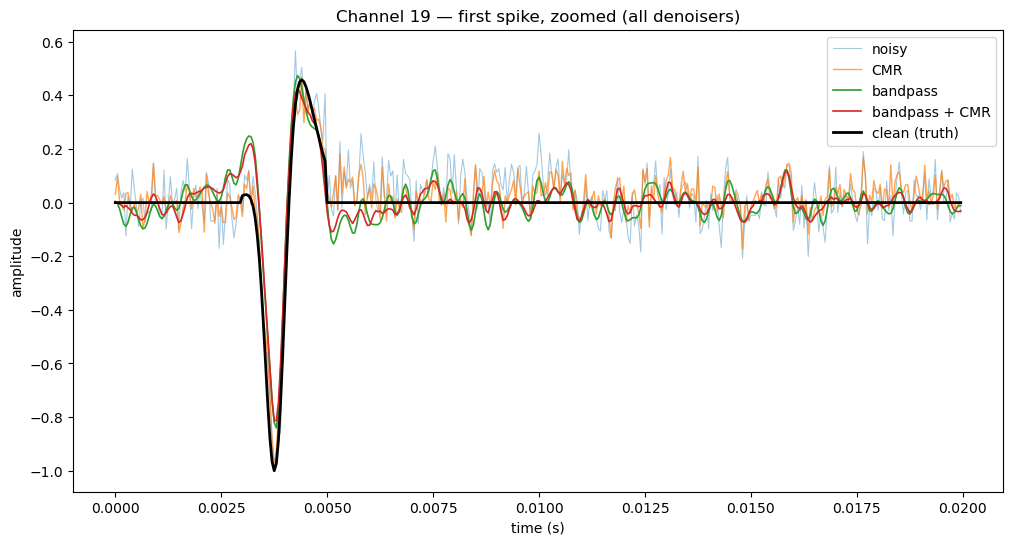

In [134]:
start = 0
end   = int(0.02 * fs)      # first 20 ms

plt.figure(figsize=(12, 6))
plt.plot(t_axis[start:end], noisy[ch, start:end],       lw=0.8, alpha=0.4, label="noisy")
plt.plot(t_axis[start:end], cmr[ch, start:end],         lw=1.0, alpha=0.7, label="CMR")
plt.plot(t_axis[start:end], bp[ch, start:end],          lw=1.2, label="bandpass")
plt.plot(t_axis[start:end], bp_then_cmr[ch, start:end], lw=1.2, label="bandpass + CMR")
plt.plot(t_axis[start:end], rec[ch, start:end],         lw=2.0, color='k', label="clean (truth)")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — first spike, zoomed (all denoisers)")
plt.legend()
plt.show()

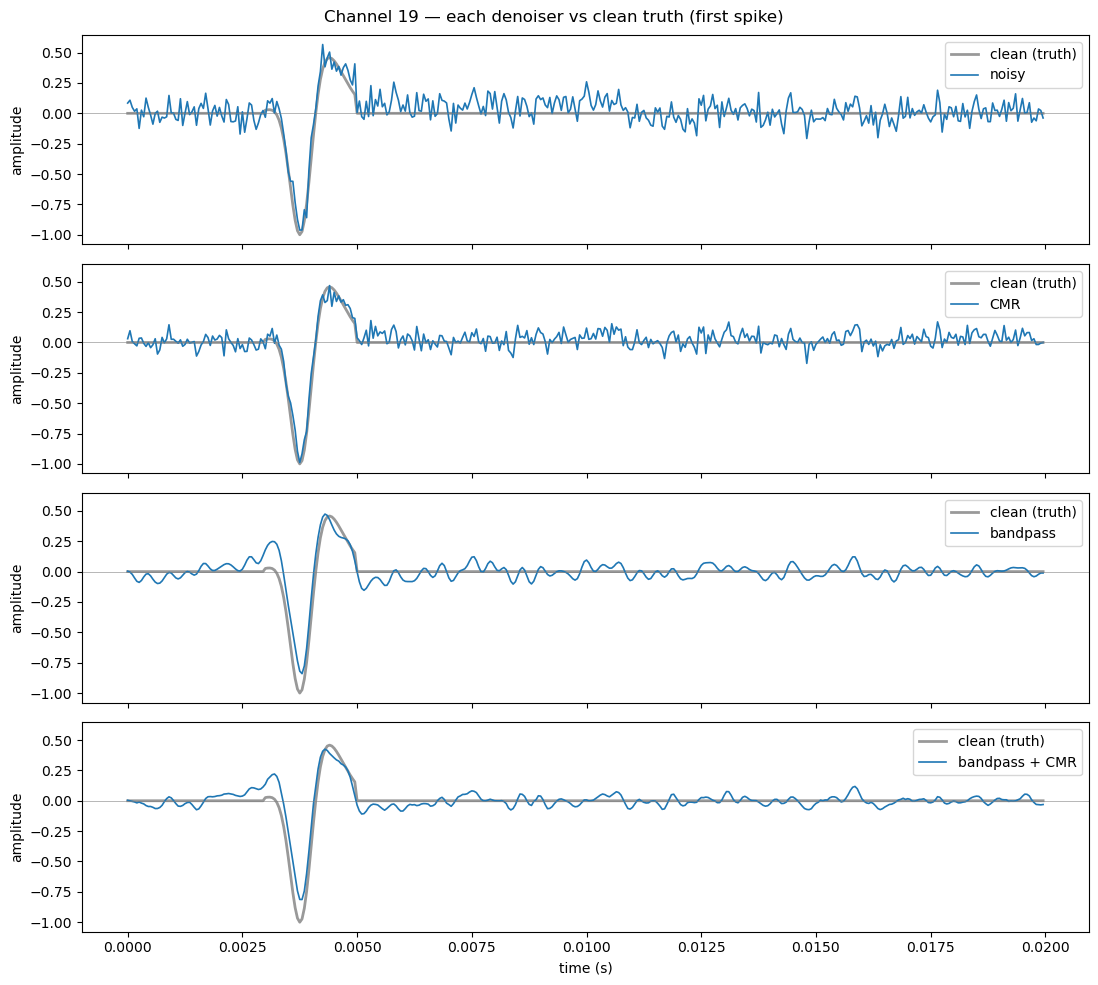

In [136]:
ch = 18   # channel 19
start = 0
end = int(0.02 * fs)      # first 20 ms (one spike)
t_zoom = t_axis[start:end]

traces = [
    ("noisy",           noisy),
    ("CMR",             cmr),
    ("bandpass",        bp),
    ("bandpass + CMR",  bp_then_cmr),
]

fig, axes = plt.subplots(len(traces), 1, figsize=(11, 10), sharex=True, sharey=True)

for ax, (name, data) in zip(axes, traces):
    ax.plot(t_zoom, rec[ch, start:end], lw=2.0, color='k', alpha=0.4, label="clean (truth)")
    ax.plot(t_zoom, data[ch, start:end], lw=1.2, label=name)
    ax.set_ylabel("amplitude")
    ax.legend(loc="upper right")
    ax.axhline(0, color='grey', lw=0.4)

axes[-1].set_xlabel("time (s)")
fig.suptitle("Channel 19 — each denoiser vs clean truth (first spike)")
plt.tight_layout()
plt.show()

In [140]:
#Sweep figure
cfs = [0.0, 0.25, 0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

rmse_noisy_sweep, rmse_bp_sweep, rmse_cmr_sweep, rmse_both_sweep = [], [], [], [] 

for cf in cfs:
    noisy_cf = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)
    rmse_noisy_sweep.append(rmse(noisy_cf, rec))
    rmse_bp_sweep.append(rmse(denoise_bandpass(noisy_cf, fs), rec))
    rmse_cmr_sweep.append(rmse(denoise_cmr(noisy_cf), rec))
    rmse_both_sweep.append(rmse(denoise_cmr(denoise_bandpass(noisy_cf, fs)), rec))
    print(f"cf={cf:.2f}")
                           
    

cf=0.00
cf=0.25
cf=0.50
cf=0.70
cf=0.75
cf=0.80
cf=0.85
cf=0.90
cf=0.95
cf=1.00


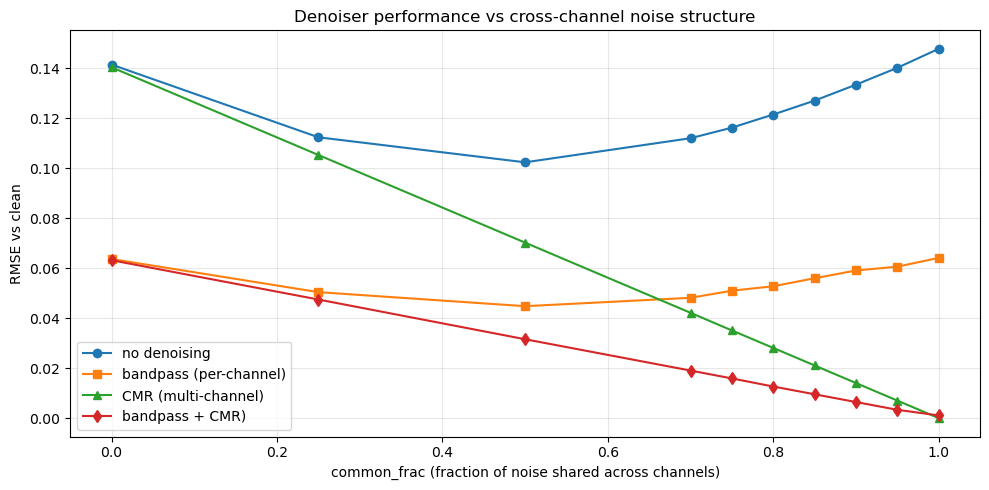

In [142]:
# plot
plt.figure(figsize=(10, 5))
plt.plot(cfs, rmse_noisy_sweep,  'o-', label="no denoising")
plt.plot(cfs, rmse_bp_sweep,  's-', label="bandpass (per-channel)")
plt.plot(cfs, rmse_cmr_sweep,  '^-',  label="CMR (multi-channel)")
plt.plot(cfs, rmse_both_sweep,  'd-',  label="bandpass + CMR)")
plt.xlabel("common_frac (fraction of noise shared across channels)")
plt.ylabel("RMSE vs clean")
plt.title("Denoiser performance vs cross-channel noise structure")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Common Average Reference (CAR)

In [145]:
def denoise_car(noisy, fs=None):
    """
    CAR is same as CMR above but uses the MEAN across channels instead of the median. 
    the mean is no not strong for ouliers, so large spike on one channel contaminates the reference and get subtracted from every channel. 
    """

    reference = np.mean(noisy, axis=0)
    denoised = noisy - reference
    return denoised

In [148]:
cf = 1.0
noisy_cf = rec +make_noise(n_channels, n_samples, fs, common_frac=cf)

car = denoise_car(noisy_cf)
cmr = denoise_cmr(noisy_cf)

print(f"common_frac = {cf}")
print("RMSE CAR:", rmse(car, rec))
print("RMSE CMR:", rmse(cmr, rec))
print()
print("channel,   clean,     CAR,     CMR")
for ch in [18, 24, 8, 2, 0]:
    print(f" ch{ch+1:2d},   {rec[ch].min():6.3f},   {car[ch].min():6.3f},    {cmr[ch].min():6.3f}")

common_frac = 1.0
RMSE CAR: 0.0015095336809407066
RMSE CMR: 1.867278771469345e-19

channel,   clean,     CAR,     CMR
 ch19,   -1.000,   -0.863,    -1.000
 ch25,   -0.700,   -0.563,    -0.700
 ch 9,   -0.600,   -0.463,    -0.600
 ch 3,   -0.150,   -0.013,    -0.150
 ch 1,    0.000,   -0.063,     0.000
